In [22]:
%matplotlib inline
import os
import glob
import numpy as np
from galfitx.source_detection import SExtractor_HDR
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import shutil
from astropy.stats import sigma_clipped_stats
from astropy.table import Table
from astropy.io import ascii    

In [23]:
from astropy.visualization import simple_norm
from pathlib import Path

def save_fig(fig, fig_name, root = '.', fig_extension="pdf", resolution=300):
    IMAGES_PATH = Path(root)
    IMAGES_PATH = IMAGES_PATH.expanduser()
    IMAGES_PATH.mkdir(parents=True, exist_ok=True)
    path = IMAGES_PATH / f"{fig_name}.{fig_extension}"
    fig.savefig(path, format=fig_extension, dpi=resolution)

def my_im_show(data, fig=None, ax=None, norm=None, vmin_arg=2, vmax_arg=10, sigma=3,
               norm_choise='asinh', colorbar=True, unit=None, cmap='seismic',
               binary=False, non_neg=False):
    """Display an image with a concise API.

    Supports the usual astropy/simple_norm stretches (e.g. 'asinh').

    Returns: (fig, ax, im, norm)
    """

    # normalize parameter name (preserve backward compatibility)
    norm_choice = norm_choise

    # create axes if needed
    if ax is None:
        fig = plt.figure(figsize=(5, 5))
        ax = fig.add_subplot(111)

    display_data = data
    display_cmap = 'gray' if binary else cmap

    # compute norm for non-binary images if not provided
    if not binary and norm is None:
        mean, median, std = sigma_clipped_stats(data, sigma=sigma)
    # compute vmin/vmax (respect non-neg option) and use astropy's simple_norm
    vmin = max(median - vmin_arg * std, 0) if non_neg else median - vmin_arg * std
    vmax = median + vmax_arg * std
    norm = simple_norm(data, norm_choice, min_cut=vmin, max_cut=vmax)

    # display
    im = ax.imshow(display_data, norm=norm, cmap=display_cmap, origin='lower', aspect='auto')

    # colorbar
    if colorbar:
        cbar = fig.colorbar(im, ax=ax)
        if unit is not None:
            cbar.set_label(unit)

    return fig, ax, im, norm

def set_plot_style():
    plt.style.use('default')
    plt.rc("xtick.major", width=1., size=8)
    plt.rc("ytick.major", width=1., size=8)
    plt.rc("xtick.minor", width=1., size=5)
    plt.rc("ytick.minor", width=1., size=5)
    plt.rc('font', family='Times New Roman')
    plt.rc('font', size=12)
    plt.rc('axes', labelsize=12, titlesize=16)
    plt.rc('legend', fontsize=12, framealpha=0.2, labelcolor="#0d0d1a")
    plt.rc('xtick',direction="in", labelsize=10)
    plt.rc('ytick',direction="in", labelsize=10)
    plt.rcParams["scatter.marker"] = "."
    plt.rcParams["grid.linestyle"] = ":"
    #plt.rcParams["figure.facecolor"] = "#0d0d1a"
    #plt.rcParams["axes.facecolor"] = "#0d0d1a"
    #plt.rcParams["axes.edgecolor"] = "#333355"
    #plt.rcParams["xtick.color"] = "#aaaacc"
    #plt.rcParams["ytick.color"] = "#aaaacc"
    #plt.rcParams["axes.labelcolor"] = "#aaaacc"
    #plt.rcParams["axes.titlecolor"] = "#ddddff"
    plt.rcParams["grid.color"] = "#555577"
set_plot_style()

In [24]:
sci_dir = '/RS2423/JWST/grism/data/direct_image/'
sci_files = sorted(glob.glob(os.path.join(sci_dir, '*resample.fits')))
print(sci_files)
print(len(sci_files))

['/RS2423/JWST/grism/data/direct_image/nircam_F115W_mosaic_resample.fits', '/RS2423/JWST/grism/data/direct_image/nircam_F200W_mosaic_resample.fits', '/RS2423/JWST/grism/data/direct_image/nircam_F356W_mosaic_resample.fits']
3


In [25]:
sci_file = sci_files[0]
band = sci_file.split('/')[-1].split('_')[-3]
print(sci_file, band)
out_path = "/RS2423/JWST/grism/data/direct_image/sextractor/"+band+"/"
psf_out_path = "/RS2423/JWST/grism/data/direct_image/psfex/"
os.makedirs(out_path, exist_ok=True)
os.makedirs(psf_out_path, exist_ok=True)

/RS2423/JWST/grism/data/direct_image/nircam_F115W_mosaic_resample.fits F115W


In [27]:
with fits.open(sci_file) as hdul:
    hdul.info()
    hdr = hdul[1].header
    data = hdul[1].data  # or hdul['SCI'].data
    coverage_mask = ((data == 0) | np.isnan(data))  # True for pixels with zero coverage or NaN
    print(f"Shape: {data.shape}")
    print(f"Min: {np.nanmin(data):.6f}")
    print(f"Max: {np.nanmax(data):.6f}")
    print(f"Mean: {np.nanmean(data):.6f}")
    print(f"Median: {np.nanmedian(data):.6f}")
    print(f"Std: {np.nanstd(data):.6f}") 

Filename: /RS2423/JWST/grism/data/direct_image/nircam_F115W_mosaic_resample.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     369   ()      
  1  SCI           1 ImageHDU        75   (21000, 12000)   float32   
  2  ERR           1 ImageHDU        10   (21000, 12000)   float32   
  3  CON           1 ImageHDU        10   (21000, 12000, 12)   int32   
  4  WHT           1 ImageHDU         9   (21000, 12000)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (21000, 12000)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (21000, 12000)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (21000, 12000)   float32   
  8  HDRTAB        1 BinTableHDU    536   384R x 263C   [23A, 5A, 3A, 48A, 7A, 13A, 6A, 5A, 6A, 7A, 10A, 4A, L, D, D, 4A, 24A, 40A, 15A, 3A, 9A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 2A, L, 39A, 10A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 10A, 23A, 5A, D, D, D, D, D, D, D, D, 7A, 6A, 5A, 1A, 5A, 

In [28]:
print(np.sum(np.isfinite(data)))
print(np.sum(np.isnan(data)))

220847429
31152571


In [63]:
hdr

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                21000                                                  
NAXIS2  =                12000                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
EXTNAME = 'SCI     '           / extension name                                 
MJD-BEG =    59813.49840402778 / [d] exposure start time in MJD                 
MJD-AVG =    59814.00297424527 / [d] exposure mid-point in MJD                  
MJD-END =      59814.963254375 / [d] exposure end time in MJD                   
TDB-BEG =    59813.50224648655 / [d] TDB time of exposure start in MJD          
TDB-MID =   59814.0068551944

In [29]:
pixel_sr = hdr['PIXAR_SR']
pixel_scale = np.sqrt(hdr['PIXAR_A2']) #arcsec/pixel
mag_zeropoint = -2.5 * np.log10((u.MJy / u.sr * (pixel_sr*u.sr**2) / (3631 * u.Jy)).cgs.value)
print(mag_zeropoint,pixel_scale) 

28.96704130984462 0.02


In [30]:
print(f"Coverage mask: {np.sum(coverage_mask)}")

Coverage mask: 31152571


#### SExtractor catalog

In [31]:
outtab, outsegm = SExtractor_HDR(
    filename=sci_file,
    file_ext=1,
    catalog_name=("coldcat_"+band, "hotcat_"+band, "outcat_"+band),
    segmap_name=("coldseg_"+band+".fits", "hotseg_"+band+".fits", "outseg_"+band+".fits"),
    path=out_path,
    back_type=(True, True),
    back_value=(0.0, 0.0),
    detect_thresh=(3, 2),
    back_size=(128, 32),
    mag_zeropoint=mag_zeropoint,
    pixel_scale=pixel_scale,
    fwhm_arcsec=0.13,
    verbose=True,
    coverage_mask = coverage_mask,
    nnw_sex = '/home/zhanghan/sextractor/config/default.nnw'
)

#outtab = ascii.read(catalog_file)

**********Cold Detection**********

Source Extraction Begins.......
detection image: /RS2423/JWST/grism/data/direct_image/nircam_F115W_mosaic_resample.fits


Weight Image Preprocessing Finished
  weight_type = NONE


Automatic Background Estimation and Subtraction Finished
  background size = 128
  background filter size = 3


Detection Finished
  detect_minarea = 5
  detect_thresh = 3
  threshold (above background) = 0.036176733672618866
Found 25970 sources.


Deblending skipped.


Cleaning skipped.


There are 25970 objects in the catalog.

obj_crowded [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, Fals

In [32]:
idx1 =  (outtab['elongation'] < 1.5) 
idx2 =  (outtab['class_star'] > 0.0) 
idx3 =  (outtab['combined_flags'] < 2) 
print(np.sum(idx1), np.sum(idx2), np.sum(idx3))

15111 69953 69953


In [33]:
outtab[0:5]

label,xcentroid,ycentroid,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,area,semimajor_sigma,semiminor_sigma,orientation,eccentricity,min_value,max_value,local_background,segment_flux,segment_fluxerr,kron_flux,kron_fluxerr,background_centroid,elongation,ellipticity,fwhm,kron_radius,flux_radius,ra,dec,cxx,cxy,cyy,gini,segment_area,mag_auto,class_star,combined_flags,global_rms
,,,,,,,pix2,pix,pix,deg,,,,,,,,,,,,pix,pix,pix,,,1 / pix2,1 / pix2,1 / pix2,,pix2,,,,
int64,float64,float64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float32
1,4407.223562739713,7.3445650495856984,4406,4408,7,8,2.0,0.7115434053796384,0.4541346930094374,14.808603787632158,0.7698383491483517,0.06569002568721771,0.08021609485149384,0.0,0.14590612053871155,0.017053878,0.18442831107116195,0.02822693132315707,0.0,1.5668113807038562,0.3617610822109477,1.4055458449189626,3.5,1.0267918579595974,15.061527494146231,28.08568776065972,2.1628612629052473,-1.4201528203868552,4.661035093070342,0.09955764097245046,5.0,30.8025,0.019272752112033026,0,0.012058912
2,4417.943837904968,7.810677048213776,4417,4419,7,9,6.0,0.7826372549599571,0.7680968269780509,45.45862004696569,0.19186543539755635,0.06154673174023628,0.13658344745635986,0.0,0.4928262010216713,0.02953818,0.45017972449449006,0.04389405901452442,0.0,1.0189304622427786,0.0185787577702905,1.825930111453678,3.5,1.0551554964589902,15.061563365197072,28.085637241228426,1.6642946653753647,-0.06238869354323621,1.66329580820372,0.19348495577503666,9.0,29.8336,0.019448669405849554,0,0.012058912
3,4439.054932742627,7.451808804586546,4437,4441,7,8,5.0,1.4021329875563635,0.4976322714318554,-0.2755086571170527,0.9349001324573407,0.044106148183345795,0.09826037287712097,0.0,0.3716851472854614,0.026964547,0.5074318051985164,0.0434009000554871,0.0,2.8176086400545435,0.6450891064911548,2.4773864068190954,3.5,1.6908595391952634,15.061640626396493,28.085541778009137,0.5087345801722988,0.03394292684641033,4.038072852430676,0.153102941030257,10.0,29.7036,0.019345569913791615,0,0.012058912
4,4448.136700853339,7.408036403538077,4447,4450,7,8,3.0,0.9666291163018818,0.482112925123815,-6.541417114830598,0.8667419290643334,0.07129783928394318,0.10117417573928833,0.0,0.24644987285137177,0.020886648,0.3787075726155777,0.03486096846788907,0.0,2.0049848612825194,0.5012431169378831,1.7986299259854566,3.5,1.3367770448116445,15.06167328965837,28.08550036220616,1.1121839317312778,0.7316119306481497,4.260371226180028,0.12122682844053599,7.0,30.0213,0.01927817494979381,0,0.012058912
5,4453.466907382463,7.980350848761749,4453,4454,7,9,4.0,0.8141954542666924,0.49889101826197213,-89.6835358816248,0.7902837113160014,0.04086374118924141,0.07228312641382217,0.0,0.22819173336029053,0.024117824,0.3512183290896935,0.03901178431764598,0.0,1.6320106485443902,0.3872589000004921,1.5899887985566454,3.693295640983853,1.1821955566992732,15.061689358756443,28.085474170416504,4.017726363667846,0.027719008840484175,1.5085673080512585,0.18059691651895568,6.0,30.1031,0.01929706649209708,0,0.012058912


In [34]:
from typing import Optional, Tuple, List
import os
import sys
from galfitx.create_psf import run_psfex
def build_input_ldac(
    sci_image: str,
    catalog_file: str,
    seg_file: str,
    output_ldac: str,
    file_ext: int = 0,
    mag_bright_limit: float = 19.0,
    mag_faint_limit: float = 21.0,
    cutout_size: int = 71,
    mask_value: float = -1e30,
    save_cutouts: bool = True,
    cutouts_dir: str = "./star_cutouts_",
    template_file: str = "./output_assoc_temp.cat",
    fwhm_arcsec: float = 0.13,
    mag_zeropoint: float = 28.0,
    ref_pixel_scale: float = 0.074,
) -> None:
    """
    Build a PSFEx input LDAC catalog from selected stars.

    This function reads a SExtractor catalogue, selects suitable stars,
    extracts cutouts, and creates a FITS_LDAC file (with updated header
    keywords) that can be directly used by PSFEx.

    Parameters
    ----------
    sci_image : str
        Path to the science FITS image.
    catalog_file : str
        Path to the SExtractor output catalogue (ASCII format).
    seg_file : str
        Path to the SExtractor segmentation map.
    output_ldac : str
        Path for the output PSFEx LDAC catalog.
    mag_bright_limit : float, optional (default=19.0)
        Bright magnitude limit for star selection.
    mag_faint_limit : float, optional (default=21.0)
        Faint magnitude limit for star selection.
    cutout_size : int, optional (default=71)
        Size of the square cutout (in pixels). Must match the VIGNET
        dimensions expected in the template (or be smaller if the
        template VIGNET is larger; the column definition will be
        adjusted automatically).
    mask_value : float, optional (default=-1e30)
        Value used to mask neighbouring sources in the cutout.
    save_cutouts : bool, optional (default=True)
        If True, save individual star cutouts as FITS files.
    cutouts_dir : str, optional (default="./star_cutouts")
        Directory where cutout FITS files will be saved (if
        `save_cutouts` is True).
    template_file : str, optional (defalut="./output_assoc_temp.cat")
        Path to an existing SExtractor ASSOC output (LDAC template).
        The template must have the same column structure and a VIGNET
        size matching `cutout_size` (or larger, though the VIGNET column
        will be rebuilt automatically).        
    fwhm_arcsec : float, optional (default=0.13)
        Approximate FWHM of stars in arcsec, used to update the
        ``SEXSFWHM`` keyword in the LDAC IMHEAD.
    mag_zeropoint : float, optional (default=28.0)
        Magnitude zero-point, used to update the ``SEXMGZPT`` keyword.
    ref_pixel_scale : float, optional (default=0.074)
        Pixel scale in arcsec/pixel, used to update the ``SEXPXSCL``
        keyword.

    Notes
    -----
    The function also updates several other SExtractor keywords
    (``NAXIS1``, ``NAXIS2``, ``SEXBKGND``, ``SEXBKDEV``,
    ``SEXTHLD``, ``SEXATHLD``, ``SEXNFIN``, ``SEXPXSCL``,
    ``SEXSFWHM``, ``SEXMGZPT``) in the LDAC IMHEAD so that they
    match the current image and star selection.

    Examples
    --------
    >>> build_input_ldac(
    ...     sci_image='sci_i.fits',
    ...     catalog_file='./sex/outcat',
    ...     seg_file='./sex/outseg.fits',
    ...     output_ldac='psfex_input_assoc.cat',
    ...     mag_bright_limit=19.0,
    ...     mag_faint_limit=21.0,
    ...     cutout_size=71,
    ...     save_cutouts=True,
    ...     cutouts_dir='./star_cutouts',
    ...     template_file='output_assoc_temp.cat',    
    ... )
    17 source satisfy stellar criteria.
    Star ID 6 at (1648.6, 34.0) too close to edge, skipped.
    ...
    14 out of 17 stars are fully within the image and have been cut out.
    Cropped star images saved to ./star_cutouts/
    LDAC 文件已生成: psfex_input_assoc.cat
    已将 NAXIS1/2 更新为 4091, 4091
    """
    # --------------------------------------------------------------------
    # 1. Read catalogue and select stars
    # --------------------------------------------------------------------
    outtab = ascii.read(catalog_file)
    '''outtab1 = outtab[
        (outtab['elongation'] < 1.5) &
        (outtab['class_star'] > 0.93) &
        (outtab['combined_flags'] < 2) &
        (outtab['mag_auto'] > mag_bright_limit) &
        (outtab['mag_auto'] < mag_faint_limit)
    ]'''
    outtab1 = outtab[
        (outtab['elongation'] < 1.5) &
        (outtab['class_star'] > 0.8) &
        (outtab['combined_flags'] < 2) 
    ]
    print(f"{len(outtab1)} source satisfy stellar criteria.")

    # --------------------------------------------------------------------
    # 2. Extract coordinates (1‑indexed)
    # --------------------------------------------------------------------
    star_ids = outtab1['label']
    x_image = np.round(outtab1['xcentroid'] + 1, 3) # 1-indexed
    y_image = np.round(outtab1['ycentroid'] + 1, 3)

    # --------------------------------------------------------------------
    # 3. Load images
    # --------------------------------------------------------------------
    sci = fits.open(sci_image)[file_ext].data
    seg = fits.open(seg_file)[0].data
    ny, nx = sci.shape
    half = cutout_size // 2

    # --------------------------------------------------------------------
    # 4. Extract cutouts
    # --------------------------------------------------------------------
    # Containers for valid star cutouts
    valid_ids = []         # stars IDs that passed the boundary check
    sci_cutout_list = []   # cutout sci image data
    seg_cutout_list = []   # cutout seg image data
    valid_coords = []      # Coordinates of valid stars (cutout centers)

    for idx, (xc, yc) in enumerate(zip(x_image, y_image)):
        # Round to nearest integer pixel center
        xc_int = round(xc)
        yc_int = round(yc)
        
        # Compute slice boundaries (left-inclusive, right-exclusive)
        xmin = xc_int - half
        xmax = xc_int + half + 1
        ymin = yc_int - half
        ymax = yc_int + half + 1

        # Boundary check: the cutout must lie entirely within the image
        if xmin >= 0 and xmax <= nx and ymin >= 0 and ymax <= ny:
            obj_id = star_ids[idx]

            # Cut out science and segmentation arrays
            sci_cutout = sci[ymin:ymax, xmin:xmax].copy()
            seg_cutout = seg[ymin:ymax, xmin:xmax].copy()

            # Mask neighbouring sources
            # Any pixel where seg_cut is not 0 AND not equal to the target ID
            # gets replaced by 'mask_value'.
            mask = ((seg_cutout != 0) & (seg_cutout != obj_id)) | (np.isnan(sci_cutout))
            sci_cutout[mask] = mask_value

            valid_ids.append(obj_id)
            sci_cutout_list.append(sci_cutout)
            seg_cutout_list.append(seg_cutout)
            valid_coords.append((xc, yc))
        else:
            print(f"Star ID {star_ids[idx]} at ({xc:.1f}, {yc:.1f}) too close to edge, skipped.")

    n_stars = len(valid_ids)
    print(f"{n_stars} out of {len(x_image)} stars are fully within the image and have been cut out.")

    # Save coordinates of valid stars only (those entirely within the image)
    if valid_coords:
        x_valid = np.array([c[0] for c in valid_coords])
        y_valid = np.array([c[1] for c in valid_coords])
        ids = np.array(valid_ids)
        np.savetxt(psf_out_path+'star_coordinates_'+band+'.txt', np.column_stack((x_valid, y_valid, ids)),
                   fmt=['%10.3f', '%10.3f', '%6d'])

    if n_stars == 0:
        raise RuntimeError("No valid stars found within the field of view.")

    # --------------------------------------------------------------------
    # 5. Save cutouts as individual FITS files (optional)
    # --------------------------------------------------------------------
    if save_cutouts:
        os.makedirs(cutouts_dir, exist_ok=True)
        for obj_id, star_data, seg_data, (xc, yc) in zip(
            valid_ids, sci_cutout_list, seg_cutout_list, valid_coords
        ):
            hdu = fits.PrimaryHDU(star_data)
            hdu.header['OBJID'] = (obj_id, 'Original  ID')
            hdu.header['CUTX'] = (xc, 'Original x centroid (1-indexed)')
            hdu.header['CUTY'] = (yc, 'Original y centroid (1-indexed)')
            hdu.header['SIZE'] = (cutout_size, 'Cutout size in pixels')
            outname = os.path.join(cutouts_dir, f"star{obj_id}.fits")
            hdu.writeto(outname, overwrite=True)

            # Segmentation cutout
            hdu_seg = fits.PrimaryHDU(seg_data.astype(np.int32))
            hdu_seg.header['OBJID'] = (obj_id, 'Original SExtractor ID')
            hdu_seg.header['CUTX'] = (xc, 'Original x centroid (1-indexed)')
            hdu_seg.header['CUTY'] = (yc, 'Original y centroid (1-indexed)')
            hdu_seg.header['SIZE'] = (cutout_size, 'Cutout size in pixels')
            outname_seg = os.path.join(cutouts_dir, f"star{obj_id}_seg.fits")
            hdu_seg.writeto(outname_seg, overwrite=True)
        print(f"Cropped star images saved to {cutouts_dir}/")

    # --------------------------------------------------------------------
    # 6. Prepare data arrays for the LDAC table
    # --------------------------------------------------------------------
    x_images = []
    y_images = []
    ra = []
    dec = []
    flux_radii = []
    elongations = []
    flags = []
    flux_apers = []      # FLUX_APER
    fluxerr_apers = []   # FLUXERR_APER

    for obj_id, sci_cutout, (xc, yc) in zip(
        valid_ids, sci_cutout_list, valid_coords
    ):
        row = outtab1[outtab1['label'] == obj_id]
        if len(row) != 1:
            raise ValueError(f"Star ID {obj_id} not found uniquely in outtab1.")
        x_images.append(xc)   # Use xc directly from valid_coords
        y_images.append(yc)   # Use yc directly from valid_coords
        ra.append(row['ra'][0])
        dec.append(row['dec'][0])
        flux_radii.append(row['flux_radius'][0])
        flags.append(row['combined_flags'][0])
        elongations.append(row['elongation'][0])
        flux_apers.append(row['kron_flux'][0])
        fluxerr_apers.append(row['kron_fluxerr'][0])  # 绝对误差，与 flux 同单位

    x_arr = np.array(x_images, dtype=np.float32)
    y_arr = np.array(y_images, dtype=np.float32)
    ra_arr = np.array(ra, dtype=np.float64)
    dec_arr = np.array(dec, dtype=np.float64)
    flux_arr = np.array(flux_radii, dtype=np.float32)
    elong_arr = np.array(elongations, dtype=np.float32)
    flags_arr = np.array(flags, dtype=np.int16)
    vign_arr = np.array(sci_cutout_list, dtype=np.float32)  # (n_stars, cutout_size, cutout_size)

    # Use actual flux measurements from SExtractor
    fap_arr = np.array(flux_apers, dtype=np.float32)         # FLUX_APER (absolute flux)
    ferr_arr = np.array(fluxerr_apers, dtype=np.float32)     # FLUXERR_APER (absolute error)
    snr_arr = fap_arr / ferr_arr                             # SNR_WIN = flux / flux_err
    print(f"SNR values: {snr_arr}")
    vect_assoc = np.array(x_images, dtype=np.float64)
    num_assoc = np.ones(n_stars, dtype=np.int32)

    # --------------------------------------------------------------------
    # 7. Copy template and modify hdu2 (LDAC_OBJECTS)
    # --------------------------------------------------------------------
    shutil.copy(template_file, output_ldac)

    with fits.open(output_ldac, mode='update') as hdul:
        hdu2 = hdul[2]

        # Build new column definitions, preserving everything except VIGNET
        new_cols = []
        for col in hdu2.columns:
            if col.name == 'VIGNET':
                n_pix = cutout_size * cutout_size
                new_format = f'{n_pix}E'
                new_col = fits.Column(name=col.name, format=new_format,
                                      unit=col.unit, disp=col.disp)
            else:
                new_col = fits.Column(name=col.name, format=col.format,
                                      unit=col.unit, disp=col.disp)
            new_cols.append(new_col)

        # Create new HDU with the correct number of rows
        new_hdu = fits.BinTableHDU.from_columns(
            fits.ColDefs(new_cols),
            header=hdu2.header,
            nrows=n_stars,
            fill=True,
            name='LDAC_OBJECTS'
        )

        # Fill with our data
        data = new_hdu.data
        data['X_IMAGE'][:]       = x_arr
        data['Y_IMAGE'][:]       = y_arr
        data['ALPHA_J2000'][:]   = ra_arr
        data['DELTA_J2000'][:]   = dec_arr
        data['FLUX_RADIUS'][:]   = flux_arr
        data['ELONGATION'][:]    = elong_arr
        data['FLAGS'][:]         = flags_arr
        data['VIGNET'][:]        = vign_arr.reshape(n_stars, -1)  # flattened
        data['FLUX_APER'][:]     = fap_arr
        data['FLUXERR_APER'][:]  = ferr_arr
        data['SNR_WIN'][:]       = snr_arr
        data['VECTOR_ASSOC'][:]  = vect_assoc
        data['NUMBER_ASSOC'][:]  = num_assoc

        # Update header keywords
        vign_idx = new_hdu.columns.names.index('VIGNET') + 1
        new_hdu.header[f'TDIM{vign_idx}'] = f'({cutout_size}, {cutout_size})'
        new_hdu.header['NAXIS2'] = n_stars

        # Recompute NAXIS1 (bytes per row)
        row_bytes = 0
        type_bytes = {'E':4, 'I':2, 'J':4, 'D':8, 'L':1, 'B':1, 'A':1, 'K':8}
        for col in new_hdu.columns:
            fmt = col.format.strip()
            if fmt[-1] in type_bytes:
                if fmt[:-1] == '':
                    repeat = 1
                else:
                    repeat = int(fmt[:-1])
                row_bytes += repeat * type_bytes[fmt[-1]]
        new_hdu.header['NAXIS1'] = row_bytes
        new_hdu.header['TFIELDS'] = len(new_hdu.columns)

        # Replace hdu2
        hdul[2] = new_hdu
        hdul.flush()

    print(f"LDAC 文件已生成: {output_ldac}")

    # --------------------------------------------------------------------
    # 8. Binary patch hdu1 (LDAC_IMHEAD) with up-to-date values
    # --------------------------------------------------------------------
    # Get global_rms from SExtractor catalog (already contains the correct value)
    global_rms = outtab['global_rms'][0]
    _, median_bkg, std_bkg = sigma_clipped_stats(sci, sigma=3.0, maxiters=5)

    with fits.open(sci_image) as sci_hdul:
        true_naxis1 = sci_hdul[file_ext].header['NAXIS1']
        true_naxis2 = sci_hdul[file_ext].header['NAXIS2']

    with open(output_ldac, 'rb') as f:
        raw = f.read()

    # Replacement pairs (old_bytes -> new_bytes) – must be exact length match
    raw = raw.replace(
        b'NAXIS1  =                 2000',
        f'NAXIS1  = {true_naxis1:20d}'.encode()
    )
    raw = raw.replace(
        b'NAXIS2  =                 2000',
        f'NAXIS2  = {true_naxis2:20d}'.encode()
    )
    raw = raw.replace(
        b'SEXBKGND=   4.254986066371E-03 / Median background level (ADU)',
        f'SEXBKGND= {median_bkg:20.10E} / Median background level (ADU)'.encode()
    )
    # Replace SEXBKDEV with global_rms from SExtractor catalog (critical for chi2 calculation)
    raw = raw.replace(
        b'SEXBKDEV=   1.305840630084E-02 / Median background RMS (ADU)',
        f'SEXBKDEV= {global_rms:20.10E} / Median background RMS (ADU)'.encode()
    )
    raw = raw.replace(
        b'SEXTHLD =   3.519492149353E-01 / Extraction threshold (ADU)',
        f'SEXTHLD = {std_bkg:20.10E} / Extraction threshold (ADU)'.encode()
    )
    raw = raw.replace(
        b'SEXATHLD=   3.519492149353E-01 / Analysis threshold (ADU)',
        f'SEXATHLD= {std_bkg:20.10E} / Analysis threshold (ADU)'.encode()
    )
    raw = raw.replace(
        b'SEXNFIN =                   17 / Final number of extracted sources',
        f'SEXNFIN = {n_stars:20d} / Final number of extracted sources'.encode()
    )
    raw = raw.replace(
        b'SEXPXSCL=   7.400000095367E-02 / Pixel scale used for measurements (arcsec)',
        f'SEXPXSCL= {ref_pixel_scale:20.10E} / Pixel scale used for measurements (arcsec)'.encode()
    )
    raw = raw.replace(
        b'SEXSFWHM=   1.299999952316E-01 / Source FWHM used for measurements (arcsec)',
        f'SEXSFWHM= {fwhm_arcsec:20.10E} / Source FWHM used for measurements (arcsec)'.encode()
    )
    raw = raw.replace(
        b'SEXMGZPT=          28.00000000 / Zero-point used for magnitudes',
        f'SEXMGZPT= {mag_zeropoint:20.8f} / Zero-point used for magnitudes'.encode()
    )
    raw = raw.replace(
        b'SEXGAIN =   1.985576562500E+04 / Gain used (e-/ADU)',
        f'SEXGAIN = {1.0:20.10E} / Gain used (e-/ADU)'.encode()
    )

    with open(output_ldac, 'wb') as f:
        f.write(raw)

    print(f"已将 NAXIS1/2 更新为 {true_naxis1}, {true_naxis2}")

def psfex_config(
    output_config: str = "config.psfex",
    *,
    psf_sampling: float = 0.5,
    psf_size: Tuple[int, int] = (141, 141),
    sample_autoselect: bool = True,
    sample_fwhmrange: str = "1, 5",
    sample_minsn: int = 10,
    psfvar_degrees: int = 0,
    outcat_name: str = "psfex_cat.txt"
    
) -> None:
    """
    Generate a PSFEx configuration file.

    Only the most commonly modified parameters are exposed; the remaining
    parameters use sensible defaults.  Comments are placed at the end of
    each line, following the PSFEx conventions.

    Parameters
    ----------
    output_config : str, optional (default "config.psfex")
        Path where the configuration file will be written.
    psf_sampling : float, optional (default 0.5)
        Sampling step in pixel units (0.0 = auto).
    psf_size : tuple[int, int], optional (default (141, 141))
        Image size of the PSF model.
    sample_autoselect : bool, optional (default True)
        Automatically select the FWHM? (Y/N)
    sample_fwhmrange : str, optional (default "1, 5")
        Allowed FWHM range for source selection.
    sample_minsn : int, optional (default 10)
        Minimum S/N for a source to be used.
    psfvar_degrees : int, optional (default 0)
        Polynomial degree for spatial PSF variation. 0 = constant PSF,
        1 = linear, 2 = quadratic. Use with `run_psfex(sample_positions=...)`.

    Examples
    --------
    >>> # Constant PSF (default)
    >>> psfex_config(
    ...     output_config='my_psfex.psfex',
    ...     psf_size=(101, 101),
    ... )
    >>> # Position-dependent PSF
    >>> psfex_config(
    ...     output_config='my_psfex.psfex',
    ...     psfvar_degrees=1,
    ... )
    Configuration written to my_psfex.psfex
    """
    autoselect = "Y" if sample_autoselect else "N"

    lines = [
        "# Default configuration file for PSFEx 3.21.1",
        "",
        "#-------------------------------- PSF model ----------------------------------",
        "",
        "BASIS_TYPE      PIXEL_AUTO           # NONE, PIXEL, GAUSS-LAGUERRE or FILE  PIXEL_AUTO",
        "BASIS_NUMBER    20              # Basis number or parameter",
        "BASIS_NAME      basis.fits      # Basis filename (FITS data-cube)",
        "BASIS_SCALE     1.0             # Gauss-Laguerre beta parameter",
        "NEWBASIS_TYPE   NONE            # Create new basis: NONE, PCA_INDEPENDENT",
        "                                # or PCA_COMMON",
        "NEWBASIS_NUMBER 8               # Number of new basis vectors",
        f"PSF_SAMPLING    {psf_sampling}             # Sampling step in pixel units (0.0 = auto)",
        "PSF_PIXELSIZE   1.0             # Effective pixel size in pixel step units",
        "PSF_ACCURACY    0.01            # Accuracy to expect from PSF \"pixel\" values",
        f"PSF_SIZE        {psf_size[0]}, {psf_size[1]}          # Image size of the PSF model",
        "PSF_RECENTER    Y               # Allow recentering of PSF-candidates Y/N ?",
        "MEF_TYPE        INDEPENDENT     # INDEPENDENT or COMMON",
        "",
        "#------------------------- Point source measurements -------------------------",
        "",
        "CENTER_KEYS     X_IMAGE,Y_IMAGE # Catalogue parameters for source pre-centering",
        "PHOTFLUX_KEY    FLUX_APER(1)    # Catalogue parameter for photometric norm.",
        "PHOTFLUXERR_KEY FLUXERR_APER(1) # Catalogue parameter for photometric error",
        "",
        "#----------------------------- PSF variability -------------------------------",
        "",
        "PSFVAR_KEYS     X_IMAGE,Y_IMAGE # Catalogue or FITS (preceded by :) params",
        "PSFVAR_GROUPS   1,1             # Group tag for each context key",
        f"PSFVAR_DEGREES  {psfvar_degrees}             # Polynom degree for each group (0=constant)",
        "PSFVAR_NSNAP    9               # Number of PSF snapshots per axis",
        "HIDDENMEF_TYPE  COMMON          # INDEPENDENT or COMMON",
        "STABILITY_TYPE  EXPOSURE        # EXPOSURE or SEQUENCE",
        "",
        "#----------------------------- Sample selection ------------------------------",
        "",
        f"SAMPLE_AUTOSELECT  {autoselect}            # Automatically select the FWHM (Y/N) ?",
        "SAMPLEVAR_TYPE     SEEING       # File-to-file PSF variability: NONE or SEEING",
        f"SAMPLE_FWHMRANGE   {sample_fwhmrange}",
        "SAMPLE_VARIABILITY 0.5         # Allowed FWHM variability (1.0 = 100%)",
        f"SAMPLE_MINSN       {sample_minsn}          # Minimum S/N for a source to be used",
        "SAMPLE_MAXELLIP    0.3          # Maximum (A-B)/(A+B) for a source to be used",
        "SAMPLE_FLAGMASK    0x00fe       # Rejection mask on SExtractor FLAGS",
        "SAMPLE_WFLAGMASK   0x0000       # Rejection mask on SExtractor FLAGS_WEIGHT",
        "SAMPLE_IMAFLAGMASK 0x0          # Rejection mask on SExtractor IMAFLAGS_ISO",
        "BADPIXEL_FILTER    N            # Filter bad-pixels in samples (Y/N) ?",
        "BADPIXEL_NMAX      0           # Maximum number of bad pixels allowed",
        "",
        "#----------------------- PSF homogeneisation kernel --------------------------",
        "",
        "HOMOBASIS_TYPE     NONE         # NONE or GAUSS-LAGUERRE",
        "HOMOBASIS_NUMBER   10           # Kernel basis number or parameter",
        "HOMOBASIS_SCALE    1.0          # GAUSS-LAGUERRE beta parameter",
        "HOMOPSF_PARAMS     2.0, 3.0     # Moffat parameters of the idealised PSF",
        "HOMOKERNEL_DIR                  # Where to write kernels (empty=same as input)",
        "HOMOKERNEL_SUFFIX  .homo   # Filename extension for homogenisation kernels",
        "",
        "#----------------------------- Output catalogs -------------------------------",
        "",
        "OUTCAT_TYPE        ASCII_HEAD         # NONE, ASCII_HEAD, ASCII, FITS_LDAC",
        f"OUTCAT_NAME        {outcat_name}           # Output catalog filename",
        "",
        "#------------------------------- Check-plots ----------------------------------",
        "",
        "CHECKPLOT_DEV       PDF         # NULL, XWIN, TK, PS, PSC, XFIG, PNG,",
        "                                # JPEG, AQT, PDF or SVG",
        "CHECKPLOT_RES       0           # Check-plot resolution (0 = default)",
        "CHECKPLOT_ANTIALIAS Y           # Anti-aliasing using convert (Y/N) ?",
        "",
        "CHECKPLOT_TYPE NONE",
        "",
        "CHECKIMAGE_TYPE NONE",
        "",
        "#------------------------------ Check-Images ---------------------------------",
        "#",
        "#CHECKIMAGE_TYPE SAMPLES,SNAPSHOTS_IMRES         # CHI,PROTOTYPES,SAMPLES,RESIDUALS,SNAPSHOTS",
        "#                                # or MOFFAT,-MOFFAT,-SYMMETRICAL",
        "#CHECKIMAGE_NAME results/diagnostics/samp.fits,   results/diagnostics/snap_imres.fits       #chi.fits,proto.fits,samp.fits,resi.fits,snap.fits",
        "#                                # Check-image filenames",
        "CHECKIMAGE_CUBE Y               # Save check-images as datacubes (Y/N) ?",
        "#",
        "",
        "#----------------------------- Miscellaneous ---------------------------------",
        "",
        "PSF_DIR                       # Where to write PSFs (empty=same as input)",
        "PSF_SUFFIX      .psf          # Filename extension for output PSF filename",
        "VERBOSE_TYPE    NORMAL          # can be QUIET,NORMAL,LOG or FULL",
        "WRITE_XML       N               # Write XML file (Y/N)?",
        "XML_NAME                        # Filename for XML output",
        "XSL_URL         file:///Users/mingyang/anaconda3/envs/py39/share/PSFEx/PSFEx.xsl",
        "                                # Filename for XSL style-sheet",
        "NTHREADS        1               # Number of simultaneous threads for",
        "                                # the SMP version of PSFEx",
        "                                # 0 = automatic",
    ]

    with open(output_config, "w") as f:
        f.write("\n".join(lines) + "\n")

    print(f"Configuration written to {output_config}")

In [35]:
# ========================================================================
# User-defined parameters - modify these for your data
# ========================================================================
sci_image = sci_file           # Path to science image
file_ext = 1
catalog_file = out_path+"outcat_"+band            # SExtractor catalog (ASCII)
seg_file = out_path+"outseg_"+band+".fits"           # SExtractor segmentation map
template_file = "/home/zhanghan/output_assoc_temp.cat"  # Template LDAC file

output_dir = psf_out_path # Output directory
output_ldac = psf_out_path + "psfex_" + band +".cat"           # Output LDAC catalog name

# Star selection criteria
mag_bright_limit = 19.0            # Bright magnitude limit
mag_faint_limit = 21.0             # Faint magnitude limit

# Cutout parameters
cutout_size = 71                  # Size of star cutouts (pixels)

# PSFEx configuration parameters
psf_sampling = 0.5                 # Sampling step (0.0 = auto)
psf_size = (141, 141)              # Output PSF size
sample_minsn = 100                  # Minimum S/N for star selection

# Image metadata 
fwhm_arcsec = 0.1                 # Approximate FWHM in arcsec
mag_zeropoint = mag_zeropoint               # Magnitude zero-point
ref_pixel_scale = pixel_scale       # Pixel scale (arcsec/pixel)

In [36]:
sci = fits.open(sci_image)[file_ext].data
seg = fits.open(seg_file)[0].data
print(sci.shape, seg.shape)

(12000, 21000) (12000, 21000)


In [37]:
# ========================================================================
# Step 1: Build LDAC catalog for PSFEx
# ========================================================================
print("=" * 60)
print("Step 1: Building LDAC catalog for PSFEx")
print("=" * 60)

build_input_ldac(
    sci_image=sci_image,
    catalog_file=catalog_file,
    seg_file=seg_file,
    output_ldac=output_ldac,
    file_ext = file_ext,
    mag_bright_limit=mag_bright_limit,
    mag_faint_limit=mag_faint_limit,
    cutout_size=cutout_size,
    save_cutouts=True,
    cutouts_dir=os.path.join(output_dir, "star_cutouts_"+band),
    template_file=template_file,
    fwhm_arcsec=fwhm_arcsec,
    mag_zeropoint=mag_zeropoint,
    ref_pixel_scale=ref_pixel_scale,
)

# ========================================================================
# Step 2: Generate PSFEx configuration file
# ========================================================================
print("\n" + "=" * 60)
print("Step 2: Generating PSFEx configuration file (constant PSF)")
print("=" * 60)

config_file = os.path.join(output_dir, "config"+band+".psfex")
psfex_config(
    output_config=config_file,
    psf_sampling=psf_sampling,
    psf_size=psf_size,
    sample_autoselect=True,
    sample_fwhmrange="0.5, 10",
    sample_minsn=sample_minsn,
    psfvar_degrees=0,
    outcat_name=os.path.join(output_dir, "psfex_cat_"+band+".txt")  # Constant PSF
)

# ========================================================================
# Step 3: Run PSFEx
# ========================================================================
print("\n" + "=" * 60)
print("Step 3: Running PSFEx")
print("=" * 60)

psf_file = run_psfex(
    catalog=output_ldac,
    config=config_file,
    output_dir=output_dir,
)

print("\n" + "=" * 60)
print("PSFEx workflow completed successfully!")
print(f"PSF model saved to: {psf_file}")
print(f"Output directory: {output_dir}")
print("=" * 60)

Step 1: Building LDAC catalog for PSFEx
523 source satisfy stellar criteria.
523 out of 523 stars are fully within the image and have been cut out.
Cropped star images saved to /RS2423/JWST/grism/data/direct_image/psfex/star_cutouts_F115W/
SNR values: [2.20602913e+01 3.51616211e+01 1.43758373e+01 6.47928095e+00
 2.13708382e+01 3.52273102e+01 8.84804840e+01 4.84559479e+01
 2.18536606e+01 7.61824493e+01 5.46462746e+01 4.96299248e+01
 2.19397259e+01 2.88367615e+01 1.10175073e+03 6.51549759e+01
 1.01397393e+04 2.38403564e+02 3.32736359e+01 8.06692047e+01
 7.17053909e+01 6.21384506e+01 5.76191406e+02 1.31691125e+03
 3.50573463e+01 4.50975914e+01 5.12966881e+01 5.46679192e+01
 4.85387268e+01 3.03246784e+01 4.64387787e+02 1.58924280e+03
 6.21083260e+01 3.23122673e+01 4.35083084e+01 4.46365700e+01
 3.11529297e+02 9.58395233e+01 6.26514015e+01 7.28277206e+01
 3.56346252e+02 5.98442802e+01 6.88027115e+01 4.02939746e+03
 3.60256920e+01 2.87772179e+01 2.55938306e+03 5.35443726e+01
 5.98682938e+01 

> 
----- PSFEx 3.17.1 started on 2026-07-06 at 16:05:20 with 1 thread

> 
----- 1 input catalogues:
psfex_F115W.cat     :  "no ident        "    1 extension     523 detections

> Initializing contexts...
> Reading data from psfex_F115W...
> Computing final PSF model for psfex_F115W...
   filename      [ext] accepted/total samp. chi2/dof FWHM ellip. resi. asym.
> Computing diagnostics for psfex_F115W...
psfex_F115W                 56/63      0.50  21.97   2.36  0.02  0.04  0.13
> Saving PSF model and metadata for psfex_F115W...
> 
> All done (in 1.0 s)


PSF model written to /RS2423/JWST/grism/data/direct_image/psfex/psfex_F115W.psf
PSF FITS saved to /RS2423/JWST/grism/data/direct_image/psfex/psfex_F115W_psf.fits
Radial profile saved to /RS2423/JWST/grism/data/direct_image/psfex/psfex_F115W_radial_profile.png
FWHM = 3.0332036337075414

PSFEx workflow completed successfully!
PSF model saved to: /RS2423/JWST/grism/data/direct_image/psfex/psfex_F115W.psf
Output directory: /RS2423/JWST/grism/data/direct_image/psfex/


In [38]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

psf_file = psf_out_path + "psfex_"+band+"_psf.fits"

with fits.open(psf_file) as hdul:
    hdul.info()
    psf_data = hdul[0].data  

Filename: /RS2423/JWST/grism/data/direct_image/psfex/psfex_F115W_psf.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (71, 71)   float64   


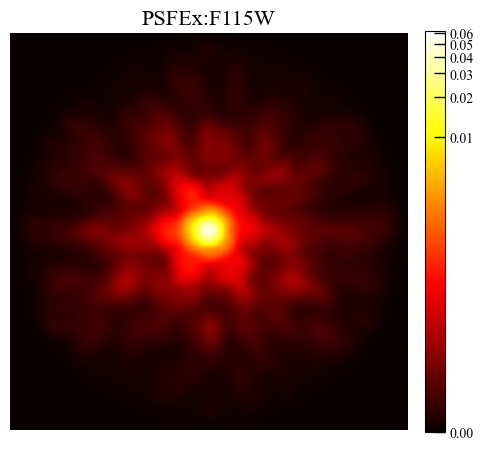

In [39]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
norm = simple_norm(psf_data, stretch='log')
im = ax.imshow(psf_data, cmap='hot', norm=norm, interpolation='gaussian', origin='lower')
ax.set_title("PSFEx:"+band)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [40]:
# PSFEx output — NUMBER is the 1-indexed row in the input LDAC
psfex_cat = ascii.read(os.path.join(output_dir, "psfex_cat_"+band+".txt"))

# star_coordinates.txt has columns: x, y, original_label
coords = np.loadtxt(os.path.join(output_dir, "star_coordinates_"+band+".txt"))

matched_ids = []
for row in psfex_cat:
    x_psf, y_psf = row['X_IMAGE'], row['Y_IMAGE']
    dx = np.abs(coords[:, 0] - x_psf)
    dy = np.abs(coords[:, 1] - y_psf)
    dist = np.sqrt(dx**2 + dy**2)
    match_idx = np.argmin(dist)
    if dist[match_idx] < 1.0:
        matched_ids.append(int(coords[match_idx, 2]))

print("Stars used by PSFEx (original IDs):", matched_ids)

Stars used by PSFEx (original IDs): [4131, 4752, 5454, 5901, 6077, 24714, 6484, 6609, 7038, 7368, 7744, 22585, 7902, 8146, 8367, 8595, 8638, 8909, 8919, 9230, 20175, 9741, 10237, 10368, 10462, 10625, 10728, 10861, 19273, 11029, 11187, 11691, 12738, 12840, 12858, 12871, 13396, 13497, 13788, 14042, 14167, 14170, 14240, 14298, 14870, 15130, 16674, 16761, 16815, 16951, 17224, 17537, 17969, 18062, 18293, 18377]


In [41]:
psf_outtab = outtab[np.isin(outtab['label'], matched_ids)]

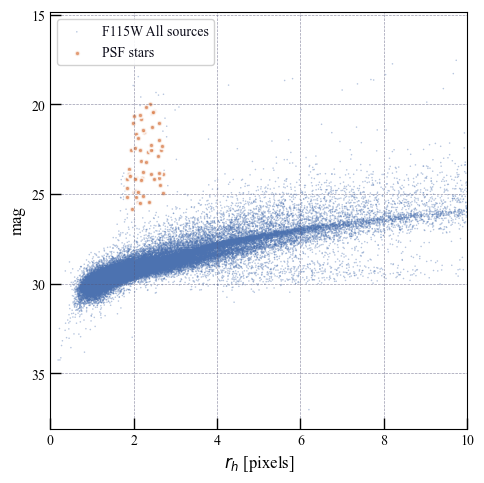

In [42]:
%matplotlib inline
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.scatter(outtab['flux_radius'], outtab['mag_auto'], s=5, alpha=0.4,
           color='#4C72B0', edgecolors='none', label=band +' All sources')
ax.scatter(psf_outtab['flux_radius'], psf_outtab['mag_auto'], s=60, alpha=0.8,
           color='#DD8452', edgecolors='white', linewidth=1.5, label='PSF stars')

ax.set_xlabel(r'$r_h$ [pixels]', fontsize=12)
ax.set_ylabel(r'mag', fontsize=12)
ax.invert_yaxis()
ax.grid(True, linestyle='--', alpha=0.6, linewidth=0.5)
ax.set_xlim(0, 10)
ax.legend(frameon=True, fancybox=True, framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.show()